In [2]:
import pandas as pd
import os
from tqdm import tqdm

from folde.data import DMS_METADATA_FILE, DMS_DIR

raw_dms_metadata = pd.read_csv(DMS_METADATA_FILE)


In [3]:

# Get percentiles of activity distribution, including "one round" activity
# (best activity discovered after one random round of screening), N round
# activity (best activity discovered after N random rounds of screening).

dms_metadata = raw_dms_metadata.copy()
ROUND_SIZE = 16
N_ROUNDS = 10

min_activity_list = []
max_activity_list = []
one_round_activity_list = []
n_round_activity_list = []

for _, row in tqdm(dms_metadata.iterrows(), total=len(dms_metadata)):
    dms_id = row["DMS_id"]
    dms_file_path = os.path.join(DMS_DIR, f"{dms_id}.csv")
    dms_df = pd.read_csv(dms_file_path)

    one_round_quantile = ROUND_SIZE / (ROUND_SIZE + 1)
    n_round_quantile = (N_ROUNDS * ROUND_SIZE) / (N_ROUNDS * ROUND_SIZE + 1)

    min_activity_list.append(dms_df["DMS_score"].min())
    max_activity_list.append(dms_df["DMS_score"].max())
    one_round_activity_list.append(dms_df["DMS_score"].quantile(one_round_quantile))
    n_round_activity_list.append(dms_df["DMS_score"].quantile(n_round_quantile))

dms_metadata["min_activity"] = min_activity_list
dms_metadata["max_activity"] = max_activity_list
dms_metadata["one_round_activity"] = one_round_activity_list
dms_metadata["n_round_activity"] = n_round_activity_list



  0%|          | 0/217 [00:00<?, ?it/s]

100%|██████████| 217/217 [00:08<00:00, 24.59it/s]


In [4]:
dms_metadata

,DMS_id,DMS_filename,UniProt_ID,taxon,source_organism,target_seq,seq_len,includes_multiple_mutants,DMS_total_number_mutants,DMS_number_single_mutants,...,weight_file_name,pdb_file,pdb_range,ProteinGym_version,raw_mut_offset,coarse_selection_type,min_activity,max_activity,one_round_activity,n_round_activity
0,A0A140D2T1_ZIKV_Sourisseau_2019,A0A140D2T1_ZIKV_Sourisseau_2019.csv,A0A140D2T1_ZIKV,Virus,Zika virus (ZIKV),MKNPKKKSGGFRIVNMLKRGVARVNPLGGLKRLPAGLLLGHGPIRM...,3423,False,9576,9576,...,A0A140D2T1_ZIKV_theta_0.01.npy,A0A140D2T1_ZIKV.pdb,291-794,0.1,NaN,OrganismalFitness,0.002354,8.439089,0.699767,2.702880
1,A0A192B1T2_9HIV1_Haddox_2018,A0A192B1T2_9HIV1_Haddox_2018.csv,A0A192B1T2_9HIV1,Virus,Human immunodeficiency virus 1,MRVKGIQMNSQHLLRWGIMILGMIMICSVAGNLWVTVYYGVPVWKD...,852,False,12577,12577,...,A0A192B1T2_9HIV1_theta_0.01.npy,A0A192B1T2_9HIV1.pdb,1-852,0.1,NaN,OrganismalFitness,-10.393382,3.267178,0.463141,1.541082
2,A0A1I9GEU1_NEIME_Kennouche_2019,A0A1I9GEU1_NEIME_Kennouche_2019.csv,A0A1I9GEU1_NEIME,Prokaryote,Neisseria meningitidis,FTLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKSA...,161,False,922,922,...,A0A1I9GEU1_NEIME_theta_0.2.npy,A0A1I9GEU1_NEIME.pdb,1-161,0.1,NaN,Activity,-8.297000,6.211000,2.129588,3.934416
3,A0A247D711_LISMN_Stadelmann_2021,A0A247D711_LISMN_Stadelmann_2021.csv,A0A247D711_LISMN,Prokaryote,Listeria monocytogenes,MNINDLIREIKNKDYTVKLSGTDSNSITQLIIRVNNDGNEYVISES...,87,False,1653,1653,...,A0A247D711_LISMN_b03_theta_0.2.npy,A0A247D711_LISMN.pdb,1-87,1.0,NaN,Activity,-4.841852,0.959943,0.698217,0.898146
4,A0A2Z5U3Z0_9INFA_Doud_2016,A0A2Z5U3Z0_9INFA_Doud_2016.csv,A0A2Z5U3Z0_9INFA,Virus,Influenza A virus (A/WSN/1933(H1N1)),MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,565,False,10715,10715,...,A0A2Z5U3Z0_9INFA_theta_0.01.npy,A0A2Z5U3Z0_9INFA.pdb,1-565,0.1,NaN,OrganismalFitness,-4.920219,1.835260,-0.028556,0.802017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,VKOR1_HUMAN_Chiasson_2020_activity,VKOR1_HUMAN_Chiasson_2020_activity.csv,VKOR1_HUMAN,Human,Homo sapiens,MGSTWGSPGWVRLALCLTGLVLSLYALHVKAARARDRDYRALCDVG...,163,False,697,697,...,VKOR1_HUMAN_theta_0.2.npy,VKOR1_HUMAN.pdb,1-163,0.1,NaN,Activity,-1.027708,1.375229,1.223996,1.350408
213,VRPI_BPT7_Tsuboyama_2023_2WNM,VRPI_BPT7_Tsuboyama_2023_2WNM.csv,VRPI_BPT7,Virus,Escherichia phage T7 (Bacteriophage T7),SLSVDNKKFWATVESSEHSFEVPIYAETLDEALELAEWQYVPAGFE...,56,False,1047,1047,...,VRPI_BPT7_theta0.01_2023-08-07_b02.npy,VRPI_BPT7.pdb,1-56,1.0,NaN,Stability,-3.070674,1.169369,0.501038,0.901719
214,YAIA_ECOLI_Tsuboyama_2023_2KVT,YAIA_ECOLI_Tsuboyama_2023_2KVT.csv,YAIA_ECOLI,Prokaryote,Escherichia coli,PREAYIVTIEKGKPGQTVTWYQLRADHPKPDSLISEHPTAQEAMDA...,52,True,1890,928,...,YAIA_ECOLI_theta0.2_2023-08-07_b03.npy,YAIA_ECOLI.pdb,1-52,1.0,NaN,Stability,-5.158251,0.778521,0.046573,0.648338
215,YAP1_HUMAN_Araya_2012,YAP1_HUMAN_Araya_2012.csv,YAP1_HUMAN,Human,Homo sapiens,MDPGQQPPPQPAPQGQGQPPSQPPQGQGPPSGPGQPAPAATQAAPQ...,504,True,10075,362,...,YAP1_HUMAN_theta_0.2.npy,YAP1_HUMAN.pdb,1-504,0.1,NaN,Binding,0.003815,9.835643,2.246224,4.228403


# Find multimutants

In [5]:
dms_metadata[dms_metadata.DMS_id == 'RASK_HUMAN_Weng_2022_abundance'].iloc[0].target_seq

'MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVIDGETCLLDILDTAGQEEYSAMRDQYMRTGEGFLCVFAINNTKSFEDIHHYREQIKRVKDSEDVPMVLVGNKCDLPSRTVDTKQAQDLARSYGIPFIETSAKTRQGVDDAFYTLVREIRKHKEKMSKDGKKKKKKSKTKCVIM'

In [6]:
dms_metadata.sort_values(by='DMS_number_multiple_mutants', ascending=False).head(20)

,DMS_id,DMS_filename,UniProt_ID,taxon,source_organism,target_seq,seq_len,includes_multiple_mutants,DMS_total_number_mutants,DMS_number_single_mutants,...,weight_file_name,pdb_file,pdb_range,ProteinGym_version,raw_mut_offset,coarse_selection_type,min_activity,max_activity,one_round_activity,n_round_activity
181,SPG1_STRSG_Olson_2014,SPG1_STRSG_Olson_2014.csv,SPG1_STRSG,Prokaryote,Streptococcus sp. group G,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,448,True,536962,1045,...,SPG1_STRSG_theta_0.2.npy,SPG1_STRSG.pdb,1-448,0.1,NaN,Binding,-4.605170,3.218876,1.091059,1.811017
73,HIS7_YEAST_Pokusaeva_2019,HIS7_YEAST_Pokusaeva_2019.csv,HIS7_YEAST,Eukaryote,Saccharomyces cerevisiae,MTEQKALVKRITNETKIQIAISLKGGPLAIEHSIFPEKEAEAVAEQ...,220,True,496137,168,...,HIS7_YEAST_theta_0.2.npy,HIS7_YEAST.pdb,1-220,0.1,NaN,OrganismalFitness,0.000000,2.327481,1.062358,1.185580
124,PHOT_CHLRE_Chen_2023,PHOT_CHLRE_Chen_2023.csv,PHOT_CHLRE,Eukaryote,Chlamydomonas reinhardtii,AGLRHTFVVADATLPDCPLVYASEGFYAMTGYGPDEVLGHNARFLQ...,118,True,167529,2122,...,PHOT_CHLRE_theta0.2_2023-08-07_b02.npy,PHOT_CHLRE.pdb,1-118,1.0,NaN,Activity,0.019363,1.780455,1.115667,1.310868
182,SPG1_STRSG_Wu_2016,SPG1_STRSG_Wu_2016.csv,SPG1_STRSG,Prokaryote,Streptococcus sp. group G,MEKEKKVKYFLRKSAFGLASVSAAFLVGSTVFAVDSPIEDTPIIRN...,448,True,149360,76,...,SPG1_STRSG_b01_theta_0.2.npy,SPG1_STRSG.pdb,1-448,1.0,NaN,Binding,0.000000,8.761966,0.212979,2.782827
69,GRB2_HUMAN_Faure_2021,GRB2_HUMAN_Faure_2021.csv,GRB2_HUMAN,Human,Homo sapiens,MEAIAKYDFKATADDELSFKRGDILKVLNEECDQNWYKAELNGKDG...,217,True,63366,1034,...,GRB2_HUMAN_theta_0.2.npy,GRB2_HUMAN.pdb,1-217,0.1,NaN,OrganismalFitness,-1.803398,0.781914,0.058004,0.300325
67,GFP_AEQVI_Sarkisyan_2016,GFP_AEQVI_Sarkisyan_2016.csv,GFP_AEQVI,Eukaryote,Aequorea victoria,MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKF...,238,True,51714,1084,...,GFP_AEQVI_theta_0.2.npy,GFP_AEQVI.pdb,1-238,0.1,NaN,Activity,1.283419,4.123109,3.755789,3.897426
28,CAPSD_AAV2S_Sinai_2021,CAPSD_AAV2S_Sinai_2021.csv,CAPSD_AAV2S,Virus,Adeno-associated virus 2 (isolate Srivastava/1...,MAADGYLPDWLEDTLSEGIRQWWKLKPGPPPPKPAERHKDDSRGLV...,735,True,42328,532,...,CAPSD_AAV2S_theta_0.01.npy,CAPSD_AAV2S.pdb,1-735,0.1,NaN,OrganismalFitness,-9.544672,9.536457,3.099316,5.236915
122,PABP_YEAST_Melamed_2013,PABP_YEAST_Melamed_2013.csv,PABP_YEAST,Eukaryote,Saccharomyces cerevisiae,MADITDKTAEQLENLNIQDDQKQAATGSESQSVENSSASLYVGDLE...,577,True,37708,1187,...,PABP_YEAST_theta_0.2.npy,PABP_YEAST.pdb,1-577,0.1,NaN,OrganismalFitness,0.002352,2.868779,1.097927,1.423924
146,Q8WTC7_9CNID_Somermeyer_2022,Q8WTC7_9CNID_Somermeyer_2022.csv,Q8WTC7_9CNID,Eukaryote,Aequorea macrodactyla,MSKGEELFTGIVPVLIELDGDVHGHKFSVRGEGEGDADYGKLEIKF...,238,True,33510,1201,...,Q8WTC7_9CNID_theta_0.2.npy,Q8WTC7_9CNID.pdb,1-238,1.0,NaN,Activity,449.000000,18688.764270,10358.716019,15022.234461
143,Q6WV12_9MAXI_Somermeyer_2022,Q6WV12_9MAXI_Somermeyer_2022.csv,Q6WV12_9MAXI,Eukaryote,Pontellina plumata,MPAMKIECRITGTLNGVEFELVGGGEGTPEQGRMTNKMKSTKGALT...,222,True,31401,1141,...,Q6WV12_9MAXI_theta_0.2.npy,Q6WV12_9MAXI.pdb,1-222,1.0,NaN,Activity,590.000000,27865.002190,19224.842517,24087.999393


In [21]:
from collections import defaultdict

multimutant_dms_ids = [
    "SPG1_STRSG_Olson_2014",
    "GRB2_HUMAN_Faure_2021",
    "PABP_YEAST_Melamed_2013",

    # These three are all weirdly formed: very little double mutant data.
    "HIS7_YEAST_Pokusaeva_2019",
    "GFP_AEQVI_Sarkisyan_2016",
    "RASK_HUMAN_Weng_2022_abundance",
]

for dms_id in multimutant_dms_ids:
    dms_file_path = os.path.join(DMS_DIR, f"{dms_id}.csv")
    dms_df = pd.read_csv(dms_file_path)

    locus_count = defaultdict(int)
    mut_count = defaultdict(int)
    for mutant in dms_df.mutant:
        mut_count[len(mutant.split(':'))] += 1
        for allele_id in mutant.split(':'):
            locus_count[allele_id[1:-1]] += 1

    print(f'{dms_id} mut_count: {mut_count}')

SPG1_STRSG_Olson_2014 mut_count: defaultdict(<class 'int'>, {2: 535917, 1: 1045})
GRB2_HUMAN_Faure_2021 mut_count: defaultdict(<class 'int'>, {2: 62332, 1: 1034})
PABP_YEAST_Melamed_2013 mut_count: defaultdict(<class 'int'>, {2: 36521, 1: 1187})
HIS7_YEAST_Pokusaeva_2019 mut_count: defaultdict(<class 'int'>, {7: 115751, 8: 97639, 9: 57139, 5: 60263, 10: 22942, 6: 98869, 11: 6370, 4: 25927, 3: 7627, 2: 1475, 1: 168, 12: 1354, 18: 35, 14: 71, 15: 40, 23: 14, 13: 245, 20: 24, 19: 38, 17: 29, 16: 39, 21: 18, 28: 3, 24: 16, 27: 4, 25: 10, 22: 16, 26: 11})
GFP_AEQVI_Sarkisyan_2016 mut_count: defaultdict(<class 'int'>, {7: 2526, 4: 9387, 5: 6825, 3: 12336, 1: 1084, 6: 4298, 2: 12777, 9: 627, 10: 299, 8: 1364, 11: 118, 12: 43, 13: 23, 14: 5, 15: 2})
RASK_HUMAN_Weng_2022_abundance mut_count: defaultdict(<class 'int'>, {1: 3066, 2: 22946})


In [22]:
from tqdm import tqdm
from collections import defaultdict

single_mut_count_dicts = {}

for dms_id in multimutant_dms_ids[::-1]:
    dms_file_path = os.path.join(DMS_DIR, f"{dms_id}.csv")
    dms_df = pd.read_csv(dms_file_path)

    # For each single mutant, see how many doubles are derivative of it.
    single_mut_count = defaultdict(int)
    single_mut_rows = dms_df[dms_df.mutant.str.count(':') == 0]
    for single_mut_allele_id in tqdm(single_mut_rows.mutant):
        # Get all the doubles that are derivative of this single mutant.
        double_mut_rows = dms_df[
            (dms_df.mutant.str.contains(single_mut_allele_id)) &
            (dms_df.mutant.str.count(':') == 1)
        ]
        single_mut_count[single_mut_allele_id] = len(double_mut_rows)

    single_mut_count_dicts[dms_id] = single_mut_count


100%|██████████| 1045/1045 [03:19<00:00,  5.24it/s]


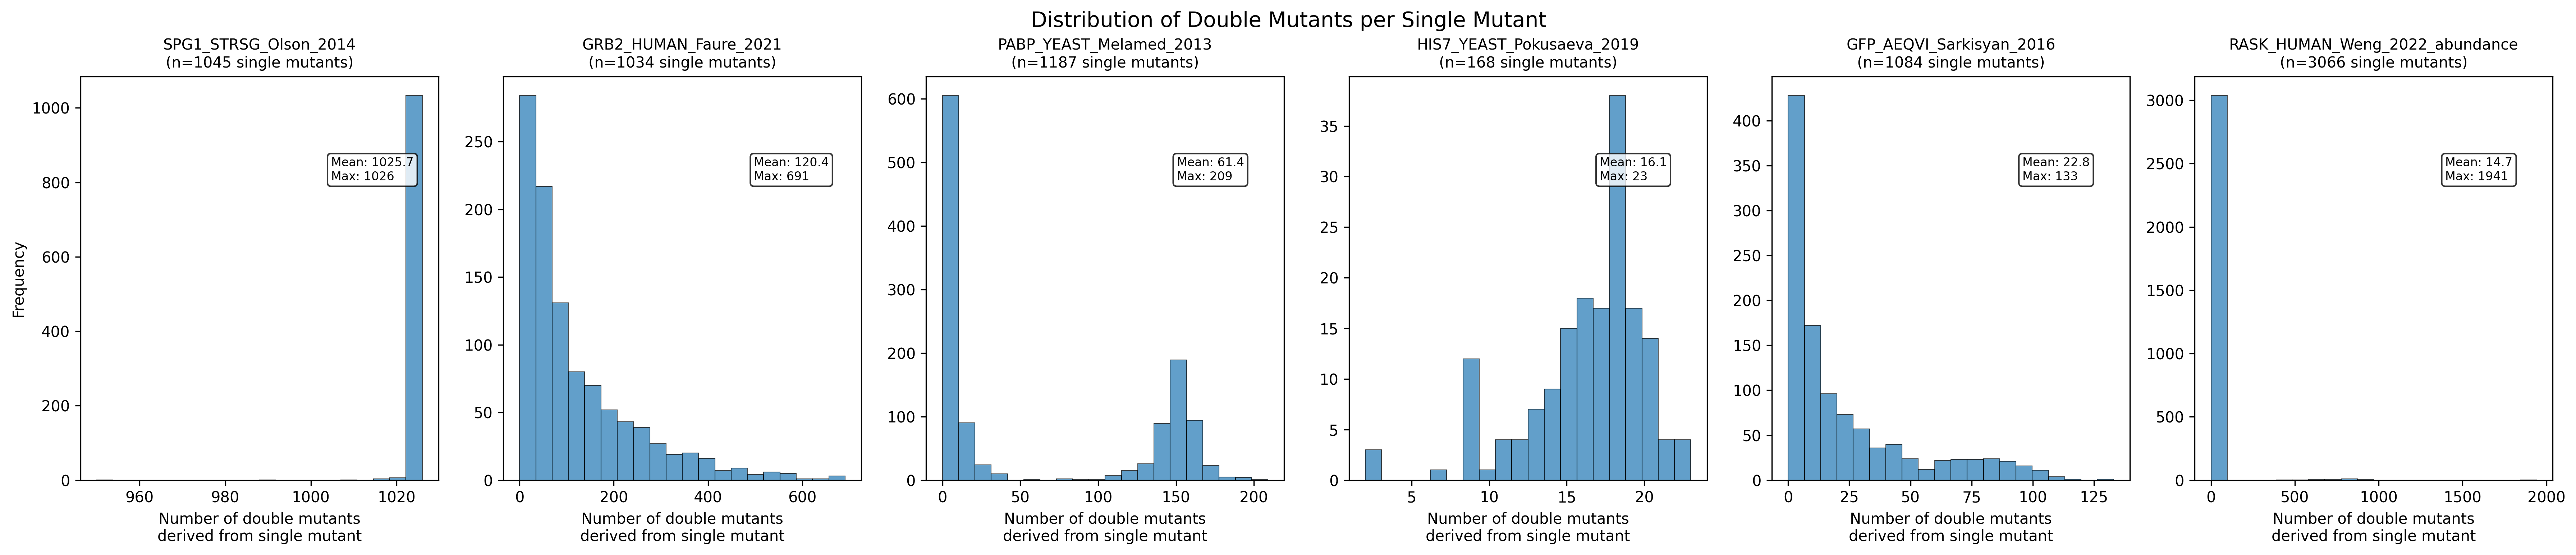

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Get the DMS IDs
dms_ids = multimutant_dms_ids

# Create subplot grid: 1 row, len(dms_ids) columns
fig, axes = plt.subplots(1, len(dms_ids), figsize=(len(dms_ids) * 4, 5), dpi=300)  # sharey=True,

# Handle case where there's only one DMS ID (axes won't be an array)
if len(dms_ids) == 1:
    axes = [axes]

for col_idx, dms_id in enumerate(dms_ids):
    ax = axes[col_idx]
    
    # Get the counts for this DMS ID
    counts = list(single_mut_count_dicts[dms_id].values())
    
    # Create histogram
    ax.hist(counts, bins=20, alpha=0.7, edgecolor='black', linewidth=0.5)
    
    # Set title and labels
    ax.set_title(f'{dms_id}\n(n={len(counts)} single mutants)', fontsize=10)
    ax.set_xlabel('Number of double mutants\nderived from single mutant')
    
    # Only set y-label for leftmost subplot
    if col_idx == 0:
        ax.set_ylabel('Frequency')
    
    # Add some statistics as text
    if counts:
        mean_count = np.mean(counts)
        max_count = np.max(counts)
        ax.text(0.7, 0.8, f'Mean: {mean_count:.1f}\nMax: {max_count}', 
                transform=ax.transAxes, fontsize=8, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# axes[0].set_yscale('log')

plt.tight_layout()
plt.suptitle('Distribution of Double Mutants per Single Mutant', fontsize=14, y=1.02)
plt.show()

# Plot Train and Test Sets

(217.0, 0.0)

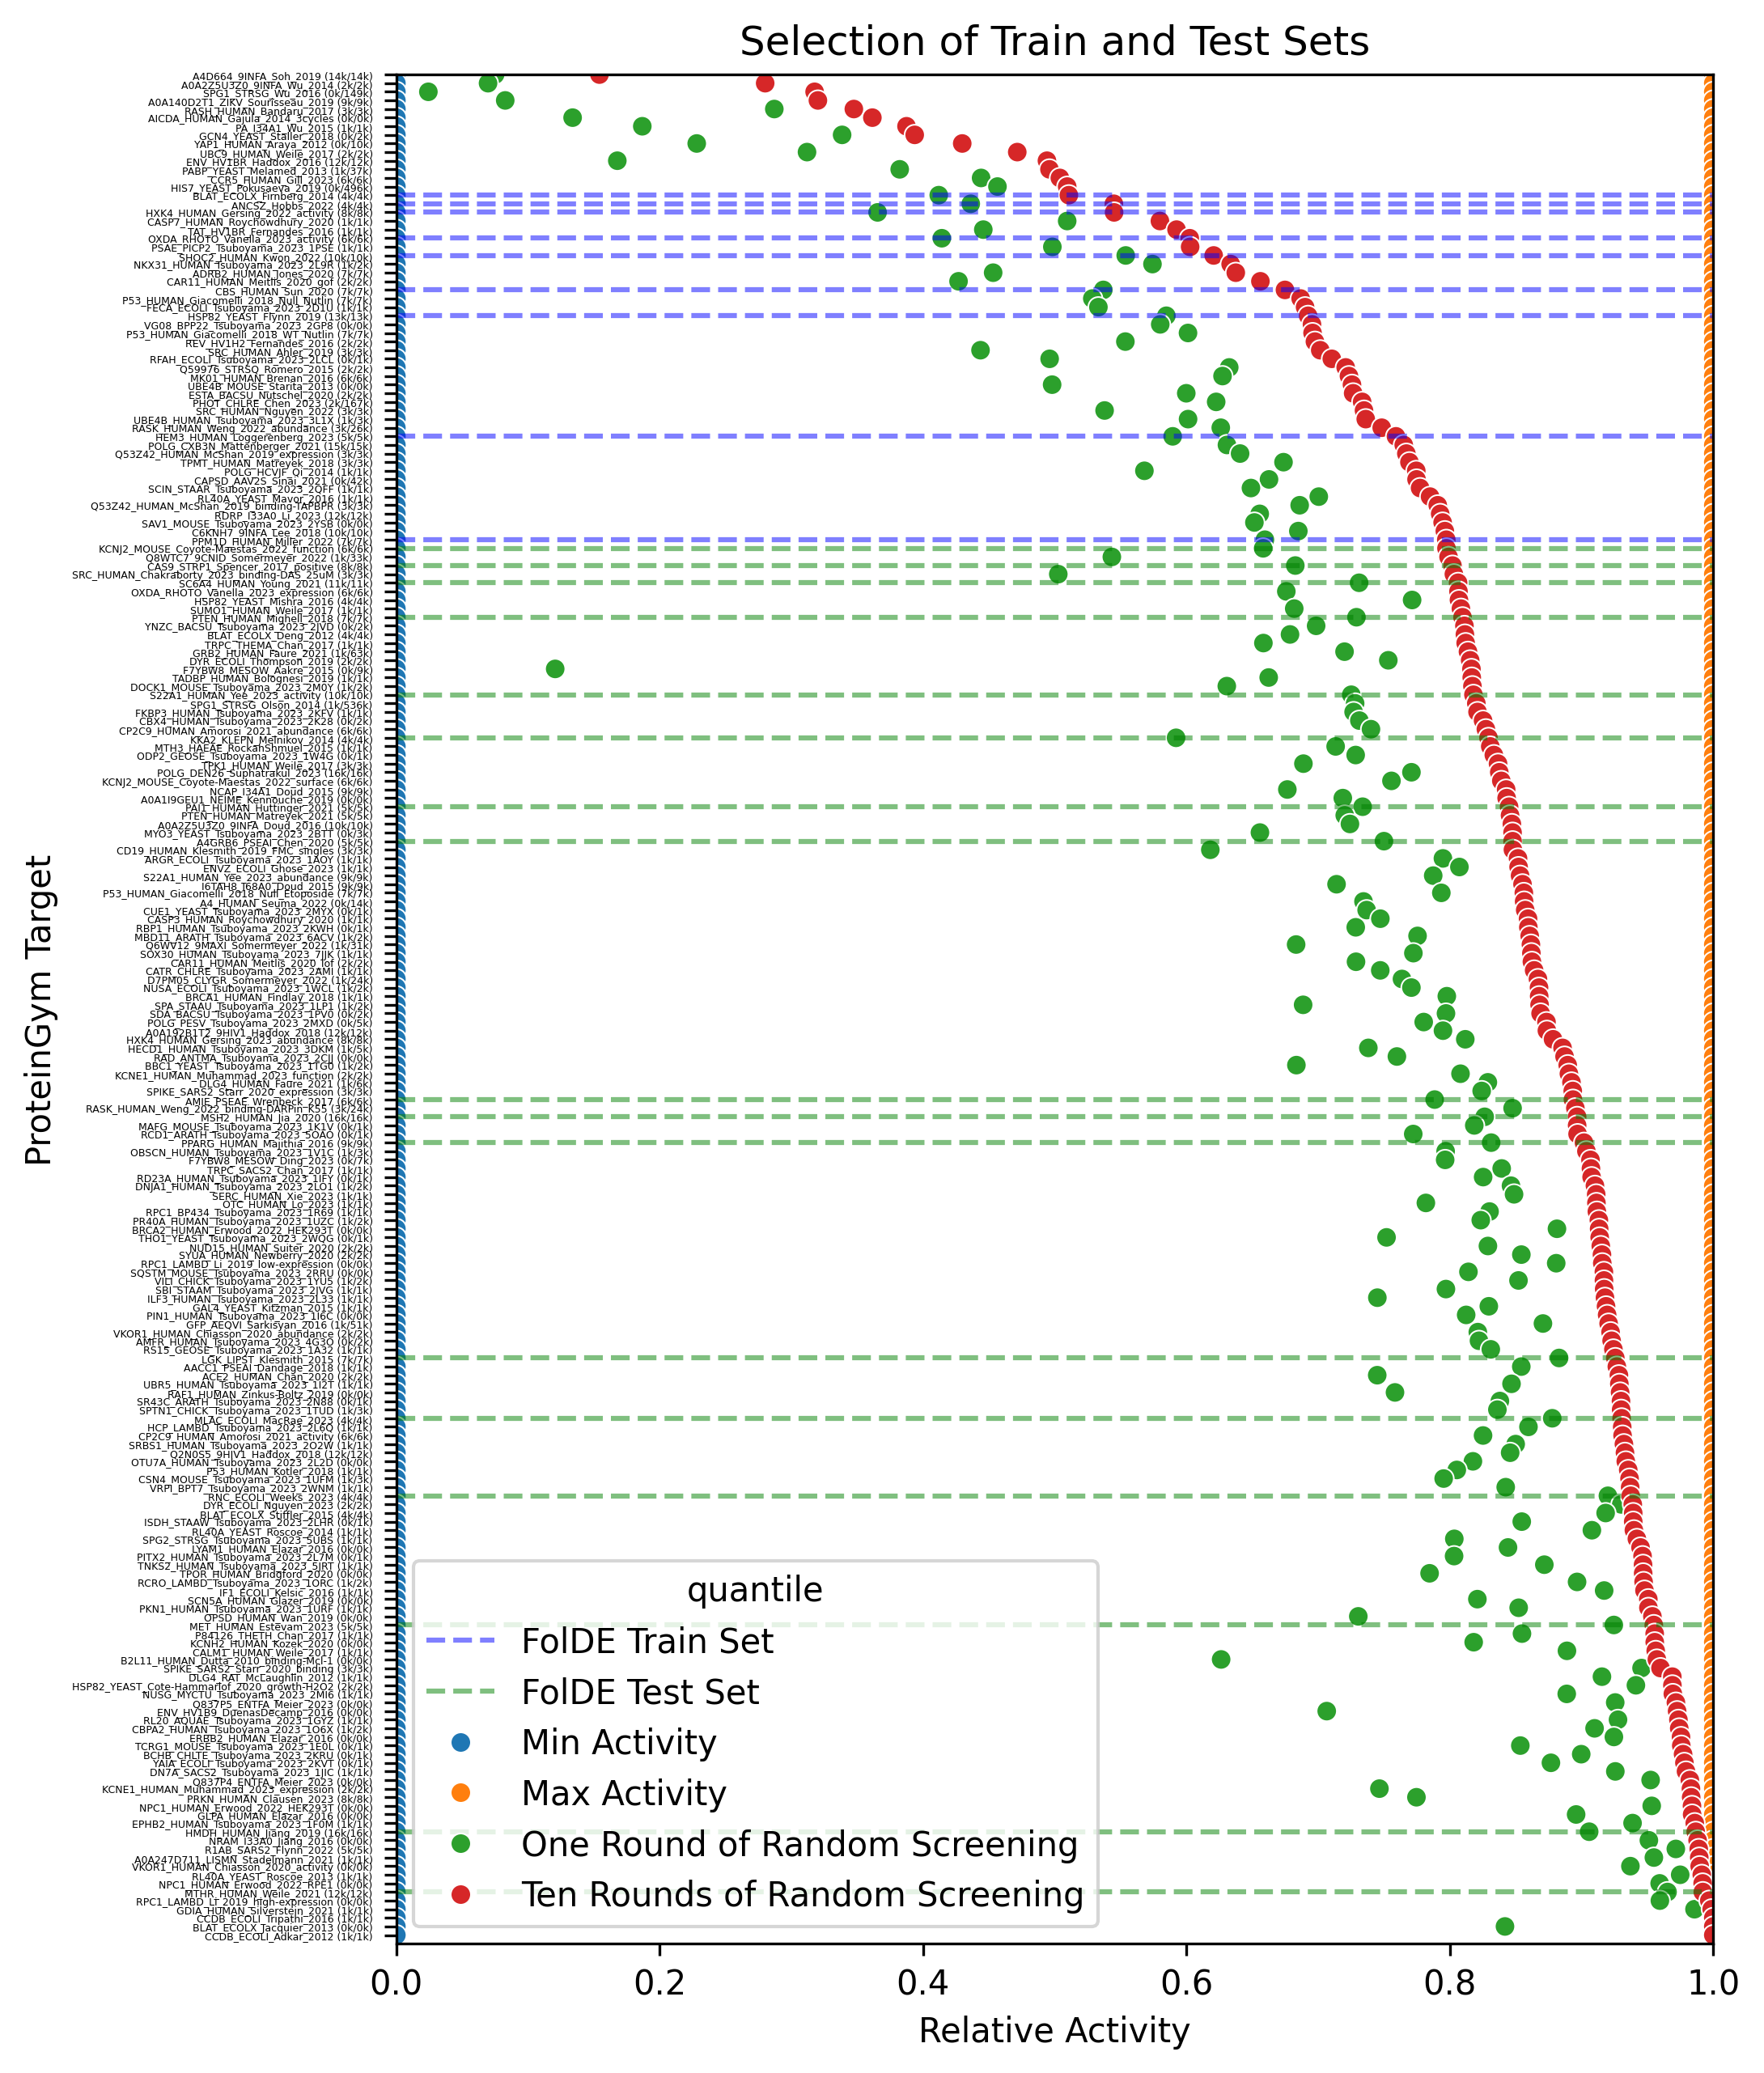

In [44]:
import seaborn as sns
from matplotlib import pyplot as plt

evolvepro_dms_ids = [
    'A0A140D2T1_ZIKV_Sourisseau_2019',
    'A0A2Z5U3Z0_9INFA_Doud_2016',
    'ADRB2_HUMAN_Jones_2020',
    'BLAT_ECOLX_Stiffler_2015',
    'C6KNH7_9INFA_Lee_2018',
    'IF1_ECOLI_Kelsic_2016',
    'MK01_HUMAN_Brenan_2016',
    'P53_HUMAN_Giacomelli_2018_Null_Etoposide',
    'PHOT_CHLRE_Chen_2023',
]

folde_train_dms_ids = [
    'ANCSZ_Hobbs_2022',
    'BLAT_ECOLX_Firnberg_2014',
    'CBS_HUMAN_Sun_2020',
    'HEM3_HUMAN_Loggerenberg_2023',
    'HSP82_YEAST_Flynn_2019',
    'HXK4_HUMAN_Gersing_2022_activity',
    'OXDA_RHOTO_Vanella_2023_activity',
    'PPM1D_HUMAN_Miller_2022',
    'SHOC2_HUMAN_Kwon_2022',
]

folde_test_dms_ids = [
    "KCNJ2_MOUSE_Coyote-Maestas_2022_function",
    "CAS9_STRP1_Spencer_2017_positive",
    "SC6A4_HUMAN_Young_2021",
    # 'OXDA_RHOTO_Vanella_2023_expression',
    # 'HSP82_YEAST_Mishra_2016',
    "PTEN_HUMAN_Mighell_2018",
    "S22A1_HUMAN_Yee_2023_activity",
    "KKA2_KLEPN_Melnikov_2014",
    # Include some "easy to engineer" targets.
    "PPARG_HUMAN_Majithia_2016",
    # 'P53_HUMAN_Giacomelli_2018_Null_Etoposide',
    "MET_HUMAN_Estevam_2023",
    "MTHR_HUMAN_Weile_2021",
    "LGK_LIPST_Klesmith_2015",
    "AMIE_PSEAE_Wrenbeck_2017",
    "PAI1_HUMAN_Huttinger_2021",
    "A4GRB6_PSEAI_Chen_2020",
    "MSH2_HUMAN_Jia_2020",
    "MLAC_ECOLI_MacRae_2023",
    "RNC_ECOLI_Weeks_2023",
    "HMDH_HUMAN_Jiang_2019",
]

multimutant_dms_ids = [
    "GRB2_HUMAN_Faure_2021",
    "PABP_YEAST_Melamed_2013",
    "SPG1_STRSG_Olson_2014",
    # "HIS7_YEAST_Pokusaeva_2019",
        # "GFP_AEQVI_Sarkisyan_2016",
        # "RASK_HUMAN_Weng_2022_abundance",
]

plt.figure(figsize=(7, 10), dpi=300)

quantile_df = dms_metadata.copy()
quantile_df['Target Name'] = dms_metadata.apply(
    lambda row: f"{row['DMS_id']} ({int(row['DMS_number_single_mutants']/1000)}k/{int(row['DMS_total_number_mutants']/1000)}k)",
    axis=1
)
# quantile_df['Target Name'] = dms_metadata.DMS_id
quantile_df = quantile_df[["DMS_id", "Target Name", "min_activity", "max_activity", "one_round_activity", "n_round_activity"]].copy()

quantile_df = quantile_df.set_index(["DMS_id", "Target Name"])
quantile_df = quantile_df\
    .sub(quantile_df.min_activity, axis=0)\
    .div(quantile_df.max_activity - quantile_df.min_activity, axis=0)

quantile_df = quantile_df.reset_index(drop=False) \
    .sort_values(by='n_round_activity')

plot_df = quantile_df.copy()
plot_df.rename(columns={
    'n_round_activity': 'Ten Rounds of Random Screening',
    'one_round_activity': 'One Round of Random Screening',
    'min_activity': 'Min Activity',
    'max_activity': 'Max Activity',
}, inplace=True)
plot_df = plot_df.melt(id_vars=['DMS_id', 'Target Name'], var_name='quantile', value_name='relative_activity')
    # .sort_values(by='one_round_activity') \

# for dms_id in evolvepro_dms_ids:
#     pos = list(melted_quantile_df['DMS_id'].unique()).index(dms_id)
#     plt.axhline(y=pos, color='orange', linestyle='--', alpha=0.5)

for ii, dms_id in enumerate(folde_train_dms_ids):
    pos = list(plot_df['DMS_id'].unique()).index(dms_id)
    kwargs = {}
    if ii == 0:
        kwargs['label'] = 'FolDE Train Set'
    plt.axhline(y=pos, color='blue', linestyle='--', alpha=0.5, **kwargs)

for ii, dms_id in enumerate(folde_test_dms_ids):
    pos = list(plot_df['DMS_id'].unique()).index(dms_id)
    kwargs = {}
    if ii == 0:
        kwargs['label'] = 'FolDE Test Set'
    plt.axhline(y=pos, color='green', linestyle='--', alpha=0.5, **kwargs)

sns.scatterplot(data=plot_df, x='relative_activity', y='Target Name', hue='quantile')
plt.yticks(fontsize=3);
plt.title('Selection of Train and Test Sets')
plt.xlabel('Relative Activity')
plt.ylabel('ProteinGym Target')

plt.xlim(0, 1)
plt.ylim(quantile_df.shape[0], 0)


# for dms_id in evolvepro_dms_ids:
#     x_pos = list(quantile_df['DMS_id'].unique()).index(dms_id)
#     plt.axvline(x=x_pos, color='orange', linestyle='--', alpha=0.5)

# sns.scatterplot(data=quantile_df, x='Target Name', y='relative_activity', hue='quantile')
# plt.xticks(rotation=90, fontsize=3);
# plt.title('Entire activity range')
# quantile_df

In [45]:
dms_metadata

,DMS_id,DMS_filename,UniProt_ID,taxon,source_organism,target_seq,seq_len,includes_multiple_mutants,DMS_total_number_mutants,DMS_number_single_mutants,...,weight_file_name,pdb_file,pdb_range,ProteinGym_version,raw_mut_offset,coarse_selection_type,min_activity,max_activity,one_round_activity,n_round_activity
0,A0A140D2T1_ZIKV_Sourisseau_2019,A0A140D2T1_ZIKV_Sourisseau_2019.csv,A0A140D2T1_ZIKV,Virus,Zika virus (ZIKV),MKNPKKKSGGFRIVNMLKRGVARVNPLGGLKRLPAGLLLGHGPIRM...,3423,False,9576,9576,...,A0A140D2T1_ZIKV_theta_0.01.npy,A0A140D2T1_ZIKV.pdb,291-794,0.1,NaN,OrganismalFitness,0.002354,8.439089,0.699767,2.702880
1,A0A192B1T2_9HIV1_Haddox_2018,A0A192B1T2_9HIV1_Haddox_2018.csv,A0A192B1T2_9HIV1,Virus,Human immunodeficiency virus 1,MRVKGIQMNSQHLLRWGIMILGMIMICSVAGNLWVTVYYGVPVWKD...,852,False,12577,12577,...,A0A192B1T2_9HIV1_theta_0.01.npy,A0A192B1T2_9HIV1.pdb,1-852,0.1,NaN,OrganismalFitness,-10.393382,3.267178,0.463141,1.541082
2,A0A1I9GEU1_NEIME_Kennouche_2019,A0A1I9GEU1_NEIME_Kennouche_2019.csv,A0A1I9GEU1_NEIME,Prokaryote,Neisseria meningitidis,FTLIELMIVIAIVGILAAVALPAYQDYTARAQVSEAILLAEGQKSA...,161,False,922,922,...,A0A1I9GEU1_NEIME_theta_0.2.npy,A0A1I9GEU1_NEIME.pdb,1-161,0.1,NaN,Activity,-8.297000,6.211000,2.129588,3.934416
3,A0A247D711_LISMN_Stadelmann_2021,A0A247D711_LISMN_Stadelmann_2021.csv,A0A247D711_LISMN,Prokaryote,Listeria monocytogenes,MNINDLIREIKNKDYTVKLSGTDSNSITQLIIRVNNDGNEYVISES...,87,False,1653,1653,...,A0A247D711_LISMN_b03_theta_0.2.npy,A0A247D711_LISMN.pdb,1-87,1.0,NaN,Activity,-4.841852,0.959943,0.698217,0.898146
4,A0A2Z5U3Z0_9INFA_Doud_2016,A0A2Z5U3Z0_9INFA_Doud_2016.csv,A0A2Z5U3Z0_9INFA,Virus,Influenza A virus (A/WSN/1933(H1N1)),MKAKLLVLLYAFVATDADTICIGYHANNSTDTVDTILEKNVAVTHS...,565,False,10715,10715,...,A0A2Z5U3Z0_9INFA_theta_0.01.npy,A0A2Z5U3Z0_9INFA.pdb,1-565,0.1,NaN,OrganismalFitness,-4.920219,1.835260,-0.028556,0.802017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212,VKOR1_HUMAN_Chiasson_2020_activity,VKOR1_HUMAN_Chiasson_2020_activity.csv,VKOR1_HUMAN,Human,Homo sapiens,MGSTWGSPGWVRLALCLTGLVLSLYALHVKAARARDRDYRALCDVG...,163,False,697,697,...,VKOR1_HUMAN_theta_0.2.npy,VKOR1_HUMAN.pdb,1-163,0.1,NaN,Activity,-1.027708,1.375229,1.223996,1.350408
213,VRPI_BPT7_Tsuboyama_2023_2WNM,VRPI_BPT7_Tsuboyama_2023_2WNM.csv,VRPI_BPT7,Virus,Escherichia phage T7 (Bacteriophage T7),SLSVDNKKFWATVESSEHSFEVPIYAETLDEALELAEWQYVPAGFE...,56,False,1047,1047,...,VRPI_BPT7_theta0.01_2023-08-07_b02.npy,VRPI_BPT7.pdb,1-56,1.0,NaN,Stability,-3.070674,1.169369,0.501038,0.901719
214,YAIA_ECOLI_Tsuboyama_2023_2KVT,YAIA_ECOLI_Tsuboyama_2023_2KVT.csv,YAIA_ECOLI,Prokaryote,Escherichia coli,PREAYIVTIEKGKPGQTVTWYQLRADHPKPDSLISEHPTAQEAMDA...,52,True,1890,928,...,YAIA_ECOLI_theta0.2_2023-08-07_b03.npy,YAIA_ECOLI.pdb,1-52,1.0,NaN,Stability,-5.158251,0.778521,0.046573,0.648338
215,YAP1_HUMAN_Araya_2012,YAP1_HUMAN_Araya_2012.csv,YAP1_HUMAN,Human,Homo sapiens,MDPGQQPPPQPAPQGQGQPPSQPPQGQGPPSGPGQPAPAATQAAPQ...,504,True,10075,362,...,YAP1_HUMAN_theta_0.2.npy,YAP1_HUMAN.pdb,1-504,0.1,NaN,Binding,0.003815,9.835643,2.246224,4.228403


In [46]:
for v in sorted(multimutant_dms_ids):
    print(f'{v}: {dms_metadata[dms_metadata.DMS_id == v].iloc[0].DMS_total_number_mutants}\r')


GRB2_HUMAN_Faure_2021: 63366
PABP_YEAST_Melamed_2013: 37708
SPG1_STRSG_Olson_2014: 536962


# Choose Single Mutant Dataset

In [17]:
def get_shortname(dms_id):
    return '_'.join(dms_id.split('_')[:2])

EVOLVE_PRO_SHORTNAMES = [get_shortname(dms_id) for dms_id in evolvepro_dms_ids]
FOLDE_TRAIN_SHORTNAMES = [get_shortname(dms_id) for dms_id in folde_train_dms_ids]

merged_df = quantile_df.merge(
    raw_dms_metadata,
    left_on='DMS_id',
    right_on='DMS_id',
    how='left'
)
merged_df['isnt_virus'] = merged_df.taxon != 'Virus'
merged_df['has_enough_singles'] = merged_df.DMS_number_single_mutants > 4000
merged_df['has_enough_total_samples'] = merged_df.DMS_total_number_mutants > 4000
merged_df['is_multimutant'] = merged_df.has_enough_total_samples & (~merged_df.has_enough_singles)
merged_df['is_activity_type'] = ~merged_df.coarse_selection_type.isin(['Binding', 'Expression'])
merged_df['short_name'] = merged_df.DMS_id.apply(lambda x: '_'.join(x.split('_')[:2]))
merged_df['used_in_evolvepro'] = merged_df.short_name.isin(EVOLVE_PRO_SHORTNAMES)
merged_df['used_in_train'] = merged_df.DMS_id.isin(folde_train_dms_ids)
merged_df['shortname_used_in_train'] = merged_df.short_name.isin(FOLDE_TRAIN_SHORTNAMES)
merged_df['qualifies'] = merged_df.isnt_virus & merged_df.has_enough_singles & merged_df.is_activity_type


DEBUG_COLS = ['DMS_id', 'short_name', 'used_in_evolvepro', 'used_in_train', 'qualifies', 'n_round_activity', 'selection_assay', 'coarse_selection_type', 'is_multimutant', 'is_activity_type', 'taxon', 'DMS_number_single_mutants', 'DMS_total_number_mutants']
merged_df[merged_df.qualifies][DEBUG_COLS]  #[merged_df.DMS_id.isin(evolvepro_dms_ids)][DEBUG_COLS]

,DMS_id,short_name,used_in_evolvepro,used_in_train,qualifies,n_round_activity,selection_assay,coarse_selection_type,is_multimutant,is_activity_type,taxon,DMS_number_single_mutants,DMS_total_number_mutants
14,BLAT_ECOLX_Firnberg_2014,BLAT_ECOLX,True,True,True,0.510649,Growth (0.25-1024 ug/mL ampicillin) doubling,OrganismalFitness,False,True,Prokaryote,4783,4783
15,ANCSZ_Hobbs_2022,ANCSZ_Hobbs,False,True,True,0.544850,successful phosphorylation of bait peptide,Activity,False,True,Eukaryote,4670,4670
16,HXK4_HUMAN_Gersing_2022_activity,HXK4_HUMAN,False,True,True,0.545003,functional complementation to reduced growth o...,OrganismalFitness,False,True,Human,8570,8570
19,OXDA_RHOTO_Vanella_2023_activity,OXDA_RHOTO,False,True,True,0.602452,fluorescent label of enzyme product,Activity,False,True,Eukaryote,6396,6396
21,SHOC2_HUMAN_Kwon_2022,SHOC2_HUMAN,False,True,True,0.620615,Drug resistance,OrganismalFitness,False,True,Human,10972,10972
23,ADRB2_HUMAN_Jones_2020,ADRB2_HUMAN,True,False,True,0.637411,"transcription (luciferase reporter, isoprotere...",Activity,False,True,Human,7800,7800
25,CBS_HUMAN_Sun_2020,CBS_HUMAN,False,True,True,0.674756,Yeast Growth,OrganismalFitness,False,True,Human,7217,7217
26,P53_HUMAN_Giacomelli_2018_Null_Nutlin,P53_HUMAN,True,False,True,0.686664,"drug resistance (nutlin-3, etoposide)",OrganismalFitness,False,True,Human,7467,7467
28,HSP82_YEAST_Flynn_2019,HSP82_YEAST,False,True,True,0.692328,"growth, nitrogen depletion (0.0125% ammonium s...",OrganismalFitness,False,True,Eukaryote,13294,13294
30,P53_HUMAN_Giacomelli_2018_WT_Nutlin,P53_HUMAN,True,False,True,0.695700,"drug resistance (nutlin-3, etoposide)",OrganismalFitness,False,True,Human,7467,7467


In [20]:
merged_df[merged_df.shortname_used_in_train &(~merged_df.used_in_train) & merged_df.qualifies][DEBUG_COLS]

,DMS_id,short_name,used_in_evolvepro,used_in_train,qualifies,n_round_activity,selection_assay,coarse_selection_type,is_multimutant,is_activity_type,taxon,DMS_number_single_mutants,DMS_total_number_mutants
61,HSP82_YEAST_Mishra_2016,HSP82_YEAST,False,False,True,0.806886,Growth,OrganismalFitness,False,True,Eukaryote,4323,4323
65,BLAT_ECOLX_Deng_2012,BLAT_ECOLX,True,False,True,0.811394,"antibiotic resistance, MIC",OrganismalFitness,False,True,Prokaryote,4996,4996
167,BLAT_ECOLX_Stiffler_2015,BLAT_ECOLX,True,False,True,0.939190,Growth (10-2500 ug/mL ampicillin),OrganismalFitness,False,True,Prokaryote,4996,4996


In [46]:
new_test_ids = merged_df[
    merged_df.qualifies &
    (~merged_df.used_in_evolvepro_or_train) &
    (~merged_df.DMS_id.isin(folde_test_dms_ids))
]
for dms_id, target_seq in new_test_ids[['DMS_id', 'target_seq']].values:
    print(f'{dms_id}')#\n{target_seq}')
    # print()

PAI1_HUMAN_Huttinger_2021
A4GRB6_PSEAI_Chen_2020
MSH2_HUMAN_Jia_2020
MLAC_ECOLI_MacRae_2023
RNC_ECOLI_Weeks_2023
HMDH_HUMAN_Jiang_2019


In [54]:
merged_df[(merged_df.qualifies) & (~merged_df.DMS_id.isin(folde_test_dms_ids))][DEBUG_COLS].head(30)
# merged_df[(merged_df.qualifies) & (~merged_df.DMS_id.isin(folde_testing_dms_ids + folde_eval_dms_ids))][DEBUG_COLS].sample(frac=1).head(20)


,DMS_id,qualifies,n_round_activity,selection_assay,coarse_selection_type,is_multimutant,is_activity_type,taxon,DMS_number_single_mutants,DMS_total_number_mutants
12,CCR5_HUMAN_Gill_2023,True,0.503817,"binding affinity, surface expression",Binding,False,False,Human,6137,6137
14,BLAT_ECOLX_Firnberg_2014,True,0.510649,Growth (0.25-1024 ug/mL ampicillin) doubling,OrganismalFitness,False,True,Prokaryote,4783,4783
15,ANCSZ_Hobbs_2022,True,0.544850,successful phosphorylation of bait peptide,Activity,False,True,Eukaryote,4670,4670
16,HXK4_HUMAN_Gersing_2022_activity,True,0.545003,functional complementation to reduced growth o...,OrganismalFitness,False,True,Human,8570,8570
19,OXDA_RHOTO_Vanella_2023_activity,True,0.602452,fluorescent label of enzyme product,Activity,False,True,Eukaryote,6396,6396
21,SHOC2_HUMAN_Kwon_2022,True,0.620615,Drug resistance,OrganismalFitness,False,True,Human,10972,10972
25,CBS_HUMAN_Sun_2020,True,0.674756,Yeast Growth,OrganismalFitness,False,True,Human,7217,7217
28,HSP82_YEAST_Flynn_2019,True,0.692328,"growth, nitrogen depletion (0.0125% ammonium s...",OrganismalFitness,False,True,Eukaryote,13294,13294
42,HEM3_HUMAN_Loggerenberg_2023,True,0.759045,activity,Activity,False,True,Human,5689,5689
54,PPM1D_HUMAN_Miller_2022,True,0.797260,Fitness with GFP reporter,OrganismalFitness,False,True,Human,7889,7889


In [ ]:
folde_eval_dms_ids = [
    'ADRB2_HUMAN_Jones_2020',
    'P53_HUMAN_Giacomelli_2018_Null_Nutlin',
    'P53_HUMAN_Giacomelli_2018_WT_Nutlin',
    'MK01_HUMAN_Brenan_2016',
    'KCNJ2_MOUSE_Coyote-Maestas_2022_function',
    'CAS9_STRP1_Spencer_2017_positive',
    'SC6A4_HUMAN_Young_2021',
    # 'OXDA_RHOTO_Vanella_2023_expression',
    # 'HSP82_YEAST_Mishra_2016',
    'PTEN_HUMAN_Mighell_2018',
    'S22A1_HUMAN_Yee_2023_activity',
    'KKA2_KLEPN_Melnikov_2014',

    # Include some "easy to engineer" targets.
    'PPARG_HUMAN_Majithia_2016',
    # 'P53_HUMAN_Giacomelli_2018_Null_Etoposide',
    'MET_HUMAN_Estevam_2023',
    'MTHR_HUMAN_Weile_2021',
    'LGK_LIPST_Klesmith_2015',
    'AMIE_PSEAE_Wrenbeck_2017',
]
merged_df.set_index('DMS_id', inplace=False).loc[folde_eval_dms_ids].reset_index()[DEBUG_COLS]

# foldy_bulk_input_df = merged_df.set_index('DMS_id', inplace=False).loc[folde_eval_dms_ids].reset_index()[['DMS_id', 'target_seq']].rename(columns={'DMS_id': 'fold_name', 'target_seq': 'chain_1_sequence'})
# foldy_bulk_input_df['chain_1_id'] = 'A'
# foldy_bulk_input_df['chain_1_type'] = 'protein'
# foldy_bulk_input_df.to_csv('notebooks/jacob/folde_eval_bulk_foldy_input.csv', index=False)

# new_benchmark_dms_ids = [
#     'BLAT_ECOLX_Firnberg_2014',
#     'ANCSZ_Hobbs_2022',
#     'HXK4_HUMAN_Gersing_2022_activity',
#     'OXDA_RHOTO_Vanella_2023_activity',
#     'SHOC2_HUMAN_Kwon_2022',
#     'ADRB2_HUMAN_Jones_2020',
#     'CBS_HUMAN_Sun_2020',
#     'P53_HUMAN_Giacomelli_2018_Null_Nutlin',
#     'HSP82_YEAST_Flynn_2019',
#     'P53_HUMAN_Giacomelli_2018_WT_Nutlin',
#     'MK01_HUMAN_Brenan_2016',
#     'HEM3_HUMAN_Loggerenberg_2023',
#     'PPM1D_HUMAN_Miller_2022',
# ]
# for row in merged_df[merged_df.DMS_id.isin(new_benchmark_dms_ids)].itertuples():
#     print(row.DMS_id, row.target_seq)

,DMS_id,qualifies,n_round_activity,selection_assay,coarse_selection_type,is_multimutant,is_activity_type,taxon,DMS_number_single_mutants,DMS_total_number_mutants
0,ADRB2_HUMAN_Jones_2020,True,0.637411,"transcription (luciferase reporter, isoprotere...",Activity,False,True,Human,7800,7800
1,P53_HUMAN_Giacomelli_2018_Null_Nutlin,True,0.686664,"drug resistance (nutlin-3, etoposide)",OrganismalFitness,False,True,Human,7467,7467
2,P53_HUMAN_Giacomelli_2018_WT_Nutlin,True,0.695700,"drug resistance (nutlin-3, etoposide)",OrganismalFitness,False,True,Human,7467,7467
3,MK01_HUMAN_Brenan_2016,True,0.723357,Growth,OrganismalFitness,False,True,Human,6809,6809
4,KCNJ2_MOUSE_Coyote-Maestas_2022_function,True,0.797398,Ion conduction,Activity,False,True,Eukaryote,6963,6963
5,CAS9_STRP1_Spencer_2017_positive,True,0.801956,count of mutation where survival depends on ex...,Activity,False,True,Prokaryote,8117,8117
6,SC6A4_HUMAN_Young_2021,True,0.806222,Fluorescence,Activity,False,True,Human,11576,11576
7,PTEN_HUMAN_Mighell_2018,True,0.809583,growth (surrogate for enzymatic activity/hydro...,Activity,False,True,Human,7260,7260
8,S22A1_HUMAN_Yee_2023_activity,True,0.817875,uptake of cytotoxic substrate,Activity,False,True,Human,10094,10094
9,KKA2_KLEPN_Melnikov_2014,True,0.829306,"Growth (225 ug/mL kanamycin) 1:1, 1:2, 1:4, 1:...",OrganismalFitness,False,True,Prokaryote,4960,4960


In [36]:
merged_df[merged_df.qualifies].iloc[0].head(100)

DMS_id                                                      CCR5_HUMAN_Gill_2023
Target Name                                         CCR5_HUMAN_Gill_2023 (6k/6k)
min_activity                                                                 0.0
max_activity                                                                 1.0
one_round_activity                                                       0.44402
n_round_activity                                                        0.503817
DMS_filename                                            CCR5_HUMAN_Gill_2023.csv
UniProt_ID                                                            CCR5_HUMAN
taxon                                                                      Human
source_organism                                                     Homo sapiens
target_seq                     MDYQVSSPIYDINYYTSEPCQKINVKQIAARLLPPLYSLVFIFGFV...
seq_len                                                                      352
includes_multiple_mutants   

In [58]:
merged_df[merged_df.DMS_id == 'CP2C9_HUMAN_Amorosi_2021_activity'].iloc[0].target_seq

'MDSLVVLVLCLSCLLLLSLWRQSSGRGKLPPGPTPLPVIGNILQIGIKDISKSLTNLSKVYGPVFTLYFGLKPIVVLHGYEAVKEALIDLGEEFSGRGIFPLAERANRGFGIVFSNGKKWKEIRRFSLMTLRNFGMGKRSIEDRVQEEARCLVEELRKTKASPCDPTFILGCAPCNVICSIIFHKRFDYKDQQFLNLMEKLNENIKILSSPWIQICNNFSPIIDYFPGTHNKLLKNVAFMKSYILEKVKEHQESMDMNNPQDFIDCFLMKMEKEKHNQPSEFTIESLENTAVDLFGAGTETTSTTLRYALLLLLKHPEVTAKVQEEIERVIGRNRSPCMQDRSHMPYTDAVVHEVQRYIDLLPTSLPHAVTCDIKFRNYLIPKGTTILISLTSVLHDNKEFPNPEMFDPHHFLDEGGNFKKSKYFMPFSAGKRICVGEALAGMELFLFLTSILQNFNLKSLVDPKNLDTTPVVNGFASVPPFYQLCFIPV'